# Finetune BERT for Downstream Tasks

*How much does BERT improve sentiment classification, why, and under what conditions?*

Description:
* Task: Binary sentiment classification (positive / negative)
* Dataset: IMDb (50k reviews with label, 50k without label)

### Load libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# torch stuff
import torch

from torch.utils.data import DataLoader

# dataset
from datasets import load_dataset
dataset = load_dataset('imdb')

# model
from transformers import BertTokenizer, BertForSequenceClassification, AutoModelForSequenceClassification

/Users/astridarhnung/anaconda3/envs/MLA/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset

Each instance consists of a text field and label (0 or 1)


`unsupervised`, label = -1

### Data preprocessing 

In [ ]:
q# split training data into 90/10 train/validation split
split_dataset = dataset['train'].train_test_split(test_size=0.1, seed=42)
dataset_train = split_dataset['train']
dataset_val = split_dataset['test']

In [3]:
# show an instance of the dataset
# print(dataset['train'][0])

In [ ]:
# print(dataset['unsupervised'][0])

In [ ]:
# dataset.column_names

In [ ]:
# print ('train:', len(dataset['train']))
# print ('unsupervised:', len(dataset['unsupervised']))
# print ('test:', len(dataset['test']))


### Split into batches

#### Tokenization

`text` input has to be processed and tokenized

In [4]:
tokenizer = BertTokenizer.from_pretrained('bert-base-cased') # or "uncased"

In [5]:
encoded_dataset_train = dataset_train.map(lambda x: tokenizer(x['text'], truncation=True, max_length=256), batched=True) 
encoded_dataset_eval = dataset_val.map(lambda x: tokenizer(x['text'], truncation=True, max_length=256), batched=True) 

In [6]:
encoded_dataset_train.column_names

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']

In [ ]:
# print (len(encoded_dataset_train['train'][0]['text']))

In [ ]:
# print (encoded_dataset_train['train'][0]['input_ids'])
# print (len(encoded_dataset_train['train'][0]['input_ids']))

In [ ]:
# print (encoded_dataset_train['train'][0]['token_type_ids'])
# print (len(encoded_dataset_train['train'][0]['token_type_ids']))

In [ ]:
# print(encoded_dataset_train['train'][0]['attention_mask'])
# print(len(encoded_dataset_train['train'][0]['attention_mask']))

# Model

## Baseline:
Suggested baseline: TF-IDF + Logistic Regression $\to$ Show a simple, interpretable reference point

Then report
- Accuracy, loss, F1-score? ...
- Training time (optional but nice)

In [7]:
# Initialize a BERT model for binary classification
model_name = "bert-base-cased"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
print(model.config)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16678.99it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tra

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.5.4",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 28996
}



### Pre-finetuning analysis (optional)

Before `trainer.train()`, **BERT’s encoder is already MLM-pretrained**; only the small classification head is random.

- **Linear probe:** train a separate logistic regression on the `[CLS]` vector from each layer (encoder frozen). Shows where sentiment is *linearly* readable without finetuning.
- **Attention:** one short example and one heatmap from **pretrained** `model.bert` (same weights the classifier will sit on).

Reduce `PROBE_N_TRAIN` / `PROBE_N_EVAL` if this section is slow on CPU.

In [ ]:
# [CLS] is a special token in BERT that is prepended to the beginning of each input sequence.
# It serves as a summary representation of the entire input, and its final hidden state
# (extracted as h[:, 0] in the code below) is commonly used for classification tasks.
#
# Linear probing: A technique to evaluate how much task-relevant information is already
# encoded in the pretrained model's representations. We freeze the BERT encoder and train
# a simple linear classifier (logistic regression) on top of the [CLS] embeddings from each layer.
# This shows where in the model the sentiment information becomes linearly separable,
# providing insights into BERT's inductive biases before fine-tuning.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader

PROBE_N_TRAIN = 2000
PROBE_N_EVAL = 1000
PROBE_BATCH = 16
PROBE_MAX_LEN = 256  # must match training max length so batches stack without a collator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


def _tokenize_fixed_length(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=PROBE_MAX_LEN,
    )


# Re-tokenize from raw text with fixed padding so every row is length PROBE_MAX_LEN
# (avoids variable-length rows from encoded_dataset_* / default DataLoader stack errors)
probe_train = (
    dataset_train.shuffle(seed=42)
    .select(range(min(PROBE_N_TRAIN, len(dataset_train))))
    .map(_tokenize_fixed_length, batched=True, remove_columns=["text"])
)
probe_eval = (
    dataset_val.shuffle(seed=42)
    .select(range(min(PROBE_N_EVAL, len(dataset_val))))
    .map(_tokenize_fixed_length, batched=True, remove_columns=["text"])
)
_probe_cols = ["input_ids", "attention_mask", "token_type_ids", "label"]
probe_train.set_format(type="torch", columns=_probe_cols)
probe_eval.set_format(type="torch", columns=_probe_cols)


@torch.no_grad()
def _cls_features_per_layer(bert, hf_dataset):
    loader = DataLoader(
        hf_dataset,
        batch_size=PROBE_BATCH,
        shuffle=False,
    )
    layer_chunks = None
    y_parts = []
    bert.eval()
    for batch in loader:
        labels = batch["label"] if "label" in batch else batch["labels"]
        inputs = {k: v.to(device) for k, v in batch.items() if k not in ("label", "labels")}
        out = bert(**inputs, output_hidden_states=True)
        stacked = torch.stack([h[:, 0].float().cpu() for h in out.hidden_states], dim=0)
        if layer_chunks is None:
            layer_chunks = [[] for _ in range(stacked.size(0))]
        for i in range(stacked.size(0)):
            layer_chunks[i].append(stacked[i])
        y_parts.append(labels.cpu())
    X_layers = [torch.cat(ch, dim=0).numpy() for ch in layer_chunks]
    y = torch.cat(y_parts, dim=0).numpy()
    return X_layers, y


Xtr, ytr = _cls_features_per_layer(model.bert, probe_train)
Xev, yev = _cls_features_per_layer(model.bert, probe_eval)

_layer_labels = ["embed"] + [f"L{i}" for i in range(model.config.num_hidden_layers)]
_acc, _f1 = [], []
for ell in range(len(Xtr)):
    clf = LogisticRegression(max_iter=500, n_jobs=-1)
    clf.fit(Xtr[ell], ytr)
    pred = clf.predict(Xev[ell])
    _acc.append(accuracy_score(yev, pred))
    _f1.append(f1_score(yev, pred, average="binary"))

for lab, a, f in zip(_layer_labels, _acc, _f1):
    print(f"{lab:5s}  acc={a:.3f}  F1={f:.3f}")

plt.figure(figsize=(8, 3))
plt.plot(range(len(_acc)), _acc, marker="o", label="accuracy")
plt.plot(range(len(_f1)), _f1, marker="s", label="F1 (binary)")
plt.xticks(range(len(_layer_labels)), _layer_labels, rotation=45, ha="right")
plt.ylabel("probe on val slice")
plt.title("Linear probe on [CLS] — frozen pretrained encoder (before finetuning)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Pretrained self-attention: one short sentence, one layer/head (qualitative only)
# SDPA / flash attention often returns an empty attentions tuple; eager materializes weights.
from transformers import AutoModel

_example = "Visually stunning but the story felt flat and forgettable."
_enc = tokenizer(_example, return_tensors="pt", truncation=True, max_length=64)
_enc = {k: v.to(device) for k, v in _enc.items()}

_viz_bert = AutoModel.from_pretrained(model_name, attn_implementation="eager")
_viz_bert.to(device).eval()
with torch.no_grad():
    _bout = _viz_bert(**_enc, output_attentions=True)

_attn = _bout.attentions
if _attn is None or len(_attn) == 0:
    raise RuntimeError("No attention weights returned; check transformers / attn_implementation.")

_layer_0based = 11
_head = 11
_layer_attn = _attn[_layer_0based]  # shape [batch, heads, seq, seq]
_A = _layer_attn[0, _head].float().cpu().numpy()
_toks = tokenizer.convert_ids_to_tokens(_enc["input_ids"][0])
plt.figure(figsize=(6, 5))
plt.imshow(_A, cmap="viridis")
plt.xticks(range(len(_toks)), _toks, rotation=90, fontsize=7)
plt.yticks(range(len(_toks)), _toks, fontsize=7)
plt.title(f"Pretrained attention — layer {_layer_0based + 1}, head {_head}")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Weights & Biases

In [8]:
import wandb

wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/astridarhnung/.netrc.
wandb: Currently logged in as: astrida (Mini-project-AML-2026) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
wandb_run = wandb.init(
    project="mini-project-aml-2026",
    entity="Mini-Project-AML-2026",
    name="bert-base-cased",
    config={
        "model_name": model_name,
        "num_labels": 2,
        "max_length": 256,
    }
)

In [13]:
def try_gpu(i=0):
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

device = try_gpu()
print(f"Using device: {device}")

Using device: cpu


## Bert (Fine-tuning)

**Core components**
- Pretrained model (e.g. bert-base-XX)
- Tokenization (module from HuggingFace)
- Loss: XX

In [ ]:

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
      return torch.device(f'cuda:{i}')
    return torch.device('cpu')
device = try_gpu()

print(f"Using device: {device}")

In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
        num_train_epochs=3,              # Number of epochs
        per_device_train_batch_size=16,  # Batch size per GPU
        per_device_eval_batch_size=16,
        learning_rate=5e-5,              # Start with a small learning rate
        # label_smoothing_factor=0.0,
        weight_decay=0.1,
        # max_grad_norm=1.0,
        save_total_limit=2,              # Limit checkpoints to save space

        # Transformers-specific config
        logging_steps=100,
        load_best_model_at_end=True, # Trainer will load the checkpoint with the best eval metric at the end of training 
        eval_strategy="epoch",
        save_strategy="epoch",
        # metric_for_best_model="accuracy",  # TODO: Do they pick the model with least validation accuracy or the final model?
        # report_to=[],  # Disable logging integrations by default
        # seed=42,
        # fp16=True,                        # Enable mixed precision for faster training
        bf16 = True,
        dataloader_pin_memory=True if torch.cuda.is_available() else False,
        output_dir=str("./results"),
        report_to = "wandb",          # tells the Trainer to push logs to W&B
        run_name = "bert-base-cased", # shown in the W&B UI
        optim="adamw_torch",   # <- important

)
# # Define training arguments
# training_args = TrainingArguments(
#     output_dir="./results",           # Directory for saving model checkpoints
#     evaluation_strategy="epoch",     # Evaluate at the end of each epoch
#     learning_rate=5e-5,              # Start with a small learning rate
#     per_device_train_batch_size=16,  # Batch size per GPU
#     per_device_eval_batch_size=16,
#     num_train_epochs=3,              # Number of epochs
#     weight_decay=0.01,               # Regularization
#     save_total_limit=2,              # Limit checkpoints to save space
#     load_best_model_at_end=True,     # Automatically load the best checkpoint
#     logging_dir="./logs",            # Directory for logs
#     logging_steps=100,               # Log every 100 steps
#     fp16=True                        # Enable mixed precision for faster training
# )

# print(args)

In [9]:
from transformers import Trainer
from evaluate import load

# Load a metric (F1-score in this case)
metric = load("f1")

# Define a custom compute_metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [10]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
trainer = Trainer(
    model=model,                        # Pre-trained BERT model
    args=args,                 # Training arguments
    train_dataset=encoded_dataset_train,
    eval_dataset=encoded_dataset_eval,
    # tokenizer=tokenizer,
    data_collator=data_collator,        # Efficient batching
    compute_metrics=compute_metrics     # Custom metric
)

# Start training
trainer.train()

# finish w&b logging
wandb.finish()   # cleanly closes the run once training is done

In [ ]:
# Evaluate the model
results = trainer.evaluate()
print(results)

### Sweep wandb configuration

In [ ]:
sweep_config = {
    "method": "bayes",  # or "random" or "grid"
    "metric": {
        "name": "eval/f1",
        "goal": "maximize"
    },
    "parameters": {
        "model_name": {
            "values": ["bert-base-cased", "bert-base-uncased", "roberta-base"]
        },
        "learning_rate": {
            "values": [2e-5, 5e-5, 1e-4]
        },
        "num_train_epochs": {
            "values": [2, 3, 5]
        },
        "weight_decay": {
            "values": [0.0, 0.1]
        },
    }
}

sweep_id = wandb.sweep(sweep_config, project="mini-project-aml-2026")

In [ ]:
def train():
    wandb.init()
    cfg = wandb.config  # access config params for this run

    # Load model using sweep param
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg.model_name, num_labels=2
    )

    args = TrainingArguments(
        output_dir="./results",
        num_train_epochs=cfg.num_train_epochs,
        learning_rate=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=100,
        report_to="wandb",
            optim="adamw_torch",   # <- important

    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["test"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    wandb.finish()

# Launch the sweep
wandb.agent(sweep_id, function=train, count=10)  # count --> max runs

### Hyperparameter tuning

## Evaluation

* Compare baseline with Bert model 
* Assumption: Bert improves sentiment analysis...

---
## Progressive Unfreezing (ULMFiT-style)

**Motivation**: The linear probe shows sentiment information becomes linearly separable from
layer ~5 onward in the *pretrained* encoder. Fine-tuning all layers simultaneously from a
randomly-initialised head risks large gradients from the head disrupting the already-useful
lower-layer representations (catastrophic forgetting).

**Strategy** (Howard & Ruder, 2018 — ULMFiT):

| Stage | Epoch | Trainable parameters |
|---|---|---|
| 1 | 1 | Classifier head only — all encoder + embeddings frozen |
| 2 | 2 | Head + top 3 transformer layers (9–11) |
| 3 | 3 | All layers — full fine-tune |

Three separate `Trainer` calls, each for 1 epoch; model weights carry over between stages.

In [ ]:
def freeze_layers(model, n_layers_to_keep_frozen: int) -> None:
    """
    Freeze BERT embeddings + the first n_layers_to_keep_frozen encoder layers.
    All remaining parameters (upper layers, pooler, classifier) are unfrozen.
    """
    total_layers = model.config.num_hidden_layers  

    # Always freeze/unfreeze embeddings alongside the bottom encoder layers
    for param in model.bert.embeddings.parameters():
        param.requires_grad = (n_layers_to_keep_frozen == 0)

    for layer_idx, layer in enumerate(model.bert.encoder.layer):
        trainable = layer_idx >= n_layers_to_keep_frozen
        for param in layer.parameters():
            param.requires_grad = trainable

    # Pooler and classifier head are always trainable
    for param in model.bert.pooler.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True


def print_frozen_status(model) -> None:
    """Print a concise summary of which parameter groups are frozen/trainable."""
    embed_frozen = not any(p.requires_grad for p in model.bert.embeddings.parameters())
    print(f"  Embeddings:  {'FROZEN' if embed_frozen else 'trainable'}")
    for i, layer in enumerate(model.bert.encoder.layer):
        frozen = not any(p.requires_grad for p in layer.parameters())
        print(f"  Layer {i:2d}:    {'FROZEN' if frozen else 'trainable'}")
    head_frozen = not any(p.requires_grad for p in model.classifier.parameters())
    print(f"  Classifier:  {'FROZEN' if head_frozen else 'trainable'}")
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable params: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.1f}%)")

In [ ]:
# Loading a fresh bert-base-cased so progressive unfreezing starts from 
# same pretrained weights as baseline to make comparisons fair.
# bf16 /fp16 can be set to true if running in colab

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import wandb

model_pu = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model_pu.to(device)

# Shared training arguments for all three stages.
def make_stage_args(stage: int, output_subdir: str) -> TrainingArguments:
    return TrainingArguments(
        output_dir=f"./results-progressive/{output_subdir}",
        num_train_epochs=1,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=5e-5,
        weight_decay=0.1,
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="no",          # no checkpointing between stages
        load_best_model_at_end=False,
        report_to="wandb",
        run_name=f"bert-progressive-unfreeze-stage{stage}",
        optim="adamw_torch",
        bf16=False,                  # set True on CUDA if available
        dataloader_pin_memory=True if torch.cuda.is_available() else False,
    )

print("Model loaded. Ready for progressive unfreezing.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15129.54it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tra

Model loaded. Ready for progressive unfreezing.


In [ ]:
wandb.init(
    project="mini-project-aml-2026",
    entity="Mini-Project-AML-2026",
    name="bert-progressive-unfreeze",
    config={
        "model": model_name,
        "strategy": "progressive_unfreeze",
        "stages": 3,
        "stage1_frozen_layers": "all (0-11) + embeddings",
        "stage2_frozen_layers": "0-8 + embeddings",
        "stage3_frozen_layers": "none",
        "lr": 5e-5,
        "batch_size": 16,
    },
    tags=["progressive-unfreeze", "ulmfit"],
)

freeze_layers(model_pu, n_layers_to_keep_frozen=12)
print("=== Stage 1: Head only ===")
print_frozen_status(model_pu)

trainer_s1 = Trainer(
    model=model_pu,
    args=make_stage_args(stage=1, output_subdir="stage1"),
    train_dataset=encoded_dataset_train,
    eval_dataset=encoded_dataset_eval,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_s1.train()

metrics_s1 = next((e for e in reversed(trainer_s1.state.log_history) if "eval_loss" in e), {})
wandb.log({"stage1/" + k: v for k, v in metrics_s1.items()})
print("Stage 1 eval:", metrics_s1)

=== Stage 1: Head only ===
  Embeddings:  FROZEN
  Layer  0:    FROZEN
  Layer  1:    FROZEN
  Layer  2:    FROZEN
  Layer  3:    FROZEN
  Layer  4:    FROZEN
  Layer  5:    FROZEN
  Layer  6:    FROZEN
  Layer  7:    FROZEN
  Layer  8:    FROZEN
  Layer  9:    FROZEN
  Layer 10:    FROZEN
  Layer 11:    FROZEN
  Classifier:  trainable
  Trainable params: 592,130 / 108,311,810 (0.5%)


Epoch,Training Loss,Validation Loss,F1
1,0.551310,0.538965,0.725866


Stage 1 eval: {'eval_loss': 0.5389646291732788, 'eval_f1': 0.7258655804480652, 'eval_runtime': 28.5896, 'eval_samples_per_second': 87.444, 'eval_steps_per_second': 5.492, 'epoch': 1.0, 'step': 1407}


In [ ]:
freeze_layers(model_pu, n_layers_to_keep_frozen=9)
print("=== Stage 2: Head + layers 9-11 ===")
print_frozen_status(model_pu)

trainer_s2 = Trainer(
    model=model_pu,
    args=make_stage_args(stage=2, output_subdir="stage2"),
    train_dataset=encoded_dataset_train,
    eval_dataset=encoded_dataset_eval,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_s2.train()

metrics_s2 = next((e for e in reversed(trainer_s2.state.log_history) if "eval_loss" in e), {})
wandb.log({"stage2/" + k: v for k, v in metrics_s2.items()})
print("Stage 2 eval:", metrics_s2)

=== Stage 2: Head + layers 9-11 ===
  Embeddings:  FROZEN
  Layer  0:    FROZEN
  Layer  1:    FROZEN
  Layer  2:    FROZEN
  Layer  3:    FROZEN
  Layer  4:    FROZEN
  Layer  5:    FROZEN
  Layer  6:    FROZEN
  Layer  7:    FROZEN
  Layer  8:    FROZEN
  Layer  9:    trainable
  Layer 10:    trainable
  Layer 11:    trainable
  Classifier:  trainable
  Trainable params: 21,855,746 / 108,311,810 (20.2%)


Epoch,Training Loss,Validation Loss,F1
1,0.244250,0.241315,0.910923


Stage 2 eval: {'eval_loss': 0.24131500720977783, 'eval_f1': 0.9109230149133414, 'eval_runtime': 27.9767, 'eval_samples_per_second': 89.36, 'eval_steps_per_second': 5.612, 'epoch': 1.0, 'step': 1407}


In [ ]:
freeze_layers(model_pu, n_layers_to_keep_frozen=0)
print("=== Stage 3: All layers (full fine-tune) ===")
print_frozen_status(model_pu)

trainer_s3 = Trainer(
    model=model_pu,
    args=make_stage_args(stage=3, output_subdir="stage3"),
    train_dataset=encoded_dataset_train,
    eval_dataset=encoded_dataset_eval,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_s3.train()

metrics_s3 = next((e for e in reversed(trainer_s3.state.log_history) if "eval_loss" in e), {})
wandb.log({"stage3/" + k: v for k, v in metrics_s3.items()})
print("Stage 3 eval:", metrics_s3)



=== Stage 3: All layers (full fine-tune) ===
  Embeddings:  trainable
  Layer  0:    trainable
  Layer  1:    trainable
  Layer  2:    trainable
  Layer  3:    trainable
  Layer  4:    trainable
  Layer  5:    trainable
  Layer  6:    trainable
  Layer  7:    trainable
  Layer  8:    trainable
  Layer  9:    trainable
  Layer 10:    trainable
  Layer 11:    trainable
  Classifier:  trainable
  Trainable params: 108,311,810 / 108,311,810 (100.0%)


Epoch,Training Loss,Validation Loss,F1
1,0.231134,0.251065,0.917468


Stage 3 eval: {'eval_loss': 0.2510654926300049, 'eval_f1': 0.9174679487179487, 'eval_runtime': 27.934, 'eval_samples_per_second': 89.497, 'eval_steps_per_second': 5.62, 'epoch': 1.0, 'step': 1407}


In [ ]:
from sklearn.metrics import accuracy_score, f1_score as sk_f1

encoded_test = dataset['test'].map(
    lambda x: tokenizer(x['text'], truncation=True, max_length=256),
    batched=True,
)

# Run inference with the last trainer (model_pu is fully unfrozen, Stage 3 weights)
test_output = trainer_s3.predict(encoded_test)
test_preds  = test_output.predictions.argmax(axis=-1)
test_labels = test_output.label_ids

acc = accuracy_score(test_labels, test_preds)
f1  = sk_f1(test_labels, test_preds, average="binary")

print("=" * 45)
print("  Progressive Unfreezing — Test Results")
print("=" * 45)
print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 (bin) : {f1:.4f}")
print("=" * 45)

# Stage-by-stage summary (for val set)
print("\nPer-stage validation F1:")
for stage, m in enumerate([metrics_s1, metrics_s2, metrics_s3], start=1):
    print(f"  Stage {stage}: F1 = {m.get('eval_f1', float('nan')):.4f}  "
          f"| loss = {m.get('eval_loss', float('nan')):.4f}")
    
wandb.finish()
print("\nProgressive unfreezing complete.")

  Progressive Unfreezing — Test Results
  Accuracy : 0.9186  (91.86%)
  F1 (bin) : 0.9185

Per-stage validation F1:
  Stage 1: F1 = 0.7259  | loss = 0.5390
  Stage 2: F1 = 0.9109  | loss = 0.2413
  Stage 3: F1 = 0.9175  | loss = 0.2511


eval/f1,▁██
eval/loss,█▁▁
eval/runtime,█▁▁
eval/samples_per_second,▁██
eval/steps_per_second,▁██
stage1/epoch,▁
stage1/eval_f1,▁
stage1/eval_loss,▁
stage1/eval_runtime,▁
stage1/eval_samples_per_second,▁
+26,...



Progressive unfreezing complete.


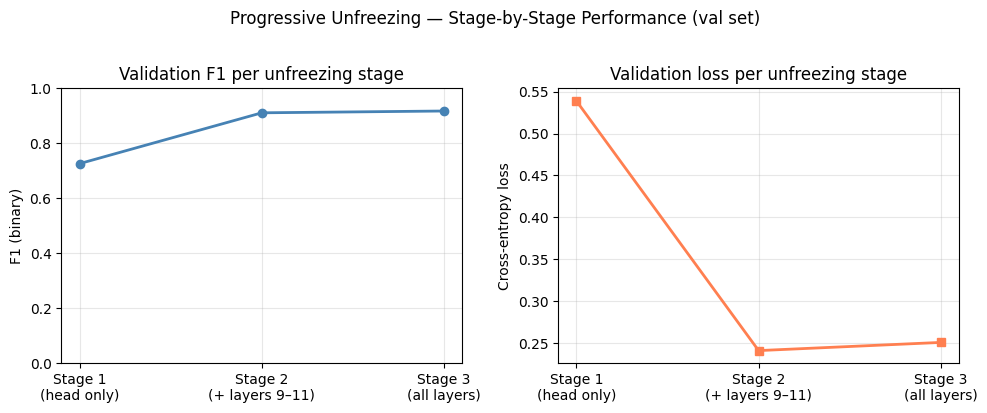

Saved: progressive_unfreeze_stages.png


In [ ]:
# Stage-by-stage comparison plot

import matplotlib.pyplot as plt

stages     = ["Stage 1\n(head only)", "Stage 2\n(+ layers 9–11)", "Stage 3\n(all layers)"]
stage_f1   = [metrics_s1.get('eval_f1',   0), metrics_s2.get('eval_f1',   0), metrics_s3.get('eval_f1',   0)]
stage_loss = [metrics_s1.get('eval_loss', 0), metrics_s2.get('eval_loss', 0), metrics_s3.get('eval_loss', 0)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(stages, stage_f1, marker='o', linewidth=2, color='steelblue')
ax1.set_ylabel('F1 (binary)')
ax1.set_title('Validation F1 per unfreezing stage')
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)

ax2.plot(stages, stage_loss, marker='s', linewidth=2, color='coral')
ax2.set_ylabel('Cross-entropy loss')
ax2.set_title('Validation loss per unfreezing stage')
ax2.grid(alpha=0.3)

plt.suptitle('Progressive Unfreezing — Stage-by-Stage Performance (val set)', y=1.02)
plt.tight_layout()
plt.savefig('progressive_unfreeze_stages.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: progressive_unfreeze_stages.png')
